# Notebook 03: Physics RLVR — Evaluation

Benchmark three models on **200 held-out** MMLU-Pro physics questions — a split that was locked before SFT or GRPO training began (seed=42) and never touched during training.

| Condition | Model | Prompt Format | Decoding |
|-----------|-------|---------------|----------|
| Base | `Qwen/Qwen3-4B-Base` | 5-shot (no XML) | Greedy |
| SFT | `qwen3-4b-physics-sft` | 0-shot XML schema | Greedy |
| GRPO | `qwen3-4b-physics-grpo` | 0-shot XML schema | Greedy |

**Why 5-shot for base?** The base model was never trained on the XML output schema — it cannot follow zero-shot XML instructions. Five in-context `Question: ... Answer: X` examples give it a fair chance to demonstrate its raw physics knowledge using a simpler format.

**Why greedy decoding?** `temperature=0` removes sampling variance from the comparison, making accuracy differences between models attributable to learning, not luck. (Residual run-to-run fluctuation comes from GPU floating-point non-determinism, not sampling.)

**Metrics**: Accuracy (primary), format compliance (SFT/GRPO only), answer extraction rate.

**Input**: `physics_rlvr/data/eval.jsonl` — 200 held-out physics MCQs  
**Output**: `physics_rlvr/outputs/evaluation_results.json`

## Step 1: Mount Google Drive and Install Dependencies

Same library stack as Notebook 02 (GRPO training) — versions are pinned to guarantee the tokenizer and model-loading API are identical across training and evaluation. `trl` is not needed here and is not installed.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/grpo-verified-reasoner
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/grpo-verified-reasoner
data			      models	    README.md			 wandb
grpo_trainer_lora_model       notebooks     src
huggingface_tokenizers_cache  outputs	    unsloth_compiled_cache
LICENSE			      physics_rlvr  _unsloth_sentencepiece_temp


In [ ]:
!nvidia-smi

Sun Mar  1 00:46:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!pip install --upgrade -qqq uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 98.2 MB/s eta 0:00:00


In [ ]:
import os
import subprocess

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:False"

In [ ]:
# Same install stack as the GRPO notebook — ensures identical environment
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth vllm
else:
    try: import numpy, PIL; get_numpy = f"numpy=={numpy.__version__}"; get_pil = f"pillow=={PIL.__version__}"
    except: get_numpy = "numpy"; get_pil = "pillow"
    try: is_t4 = "Tesla T4" in str(subprocess.check_output(["nvidia-smi"]))
    except: is_t4 = False

    get_vllm, get_triton = ("vllm==0.9.2", "triton==3.2.0") if is_t4 else ("vllm==0.10.2", "triton")

    !uv pip install -qqq --upgrade \
        unsloth {get_vllm} {get_numpy} {get_pil} torchvision bitsandbytes xformers
    !uv pip install -qqq {get_triton}

# Pin versions to match GRPO training environment
!uv pip install transformers==4.56.2
!uv pip install -q --upgrade wandb
!uv pip install --no-deps --force-reinstall unsloth==2026.1.2 unsloth-zoo==2026.1.2

Using Python 3.12.12 environment at: /usr
Resolved 18 packages in 74ms
Prepared 1 package in 470ms
Uninstalled 1 package in 61ms
Installed 1 package in 56ms
 - transformers==4.57.6
 + transformers==4.56.2
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 42ms
Prepared 2 packages in 89ms
Uninstalled 2 packages in 2ms
Installed 2 packages in 4ms
 - unsloth==2026.2.1
 + unsloth==2026.1.2
 - unsloth-zoo==2026.2.1
 + unsloth-zoo==2026.1.2


In [ ]:
import gc
import re
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from unsloth import FastLanguageModel
from vllm import SamplingParams

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
INFO 03-01 01:46:16 [__init__.py:216] Automatically detected platform cuda.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
import importlib.metadata as md
for pkg in ["unsloth", "unsloth-zoo", "vllm", "transformers"]:
    print(pkg, md.version(pkg))

unsloth 2026.1.2
unsloth-zoo 2026.1.2
vllm 0.10.2
transformers 4.56.2


In [ ]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## Step 2: Load Evaluation Data

- `eval.jsonl` — 200 held-out MMLU-Pro physics questions (never seen during SFT or GRPO)
- `sft_train.jsonl` — source for 5-shot examples (base model needs format demos)

In [ ]:
# Load held-out evaluation set
eval_dataset = load_dataset("json", data_files="physics_rlvr/data/eval.jsonl", split="train")
eval_data = [eval_dataset[i] for i in range(len(eval_dataset))]

print(f"Eval examples: {len(eval_data)}")
print("Columns:", eval_dataset.column_names)
assert len(eval_data) == 200, f"Expected 200 eval examples, got {len(eval_data)}"

# Load 5 physics/science examples from SFT data for base model's few-shot prompt
sft_dataset = load_dataset("json", data_files="physics_rlvr/data/sft_train.jsonl", split="train")
FEWSHOT_INDICES = [10, 12, 13, 14, 41]  # Physics/science rows from validation split
fewshot_examples = [sft_dataset[i] for i in FEWSHOT_INDICES]

print(f"\n5-shot examples (indices {FEWSHOT_INDICES}):")
for i, ex in enumerate(fewshot_examples):
    print(f"  [{i}] answer={ex['answer']}, q={ex['question'][:70]}...")

Eval examples: 200
Columns: ['question', 'options', 'answer']

5-shot examples (indices [10, 12, 13, 14, 41]):
  [0] answer=E, q=Say the pupil of your eye has a diameter of 5 mm and you have a telesc...
  [1] answer=H, q=A refracting telescope consists of two converging lenses separated by ...
  [2] answer=E, q=Colors in a soap bubble result from light...
  [3] answer=A, q=A microwave oven is connected to an outlet, 120 V, and draws a current...
  [4] answer=A, q=The coil of a moving coil meter has 100 turns, is 40 mm long and 30 mm...


In [ ]:
# Verify model directories exist on Drive before starting evaluation
BASE_MODEL_PATH = "unsloth/Qwen3-4B-Base"
SFT_MODEL_PATH  = "physics_rlvr/models/qwen3-4b-physics-sft"
GRPO_MODEL_PATH = "physics_rlvr/models/qwen3-4b-physics-grpo-16bit"

for name, path in [("SFT", SFT_MODEL_PATH), ("GRPO", GRPO_MODEL_PATH)]:
    assert os.path.isdir(path), f"{name} model not found at: {path}. Run notebook 01/02 first."
    print(f"{name} model found: {path}")
print(f"Base model: {BASE_MODEL_PATH} (will download from HuggingFace)")

SFT model found: physics_rlvr/models/qwen3-4b-physics-sft
GRPO model found: physics_rlvr/models/qwen3-4b-physics-grpo-16bit
Base model: unsloth/Qwen3-4B-Base (will download from HuggingFace)


## Step 3: Define Helpers and Prompt Builders

- **Base model**: 5-shot prompt with `Question:` / `Answer:` format (no XML, no chat template)
- **SFT / GRPO**: 0-shot ChatML prompt with the same XML system prompt used during training

In [ ]:
# Identical to SFT and GRPO notebooks
SYSTEM_PROMPT = """You are a physics reasoning engine.

You must output your response in the following exact format:

<START_WORKING_OUT>
Step-by-step reasoning to solve the physics problem.
</END_WORKING_OUT>
<SOLUTION>
Single letter answer only (A, B, C, D, E, F, G, H, I, or J).
</SOLUTION>

Do not output anything outside these tags."""

VALID_LETTERS = set("ABCDEFGHIJ")

# --- Schema validation (same as training notebooks) ---
RE_START   = re.compile(r"<START_WORKING_OUT>",  re.IGNORECASE)
RE_END     = re.compile(r"</END_WORKING_OUT>",   re.IGNORECASE)
RE_SOL     = re.compile(r"<SOLUTION>",           re.IGNORECASE)
RE_SOL_END = re.compile(r"</SOLUTION>",          re.IGNORECASE)


def validate_schema(text: str) -> tuple[bool, str]:
    if not RE_START.search(text):   return False, "Missing <START_WORKING_OUT>"
    if not RE_END.search(text):     return False, "Missing </END_WORKING_OUT>"
    if not RE_SOL.search(text):     return False, "Missing <SOLUTION>"
    if not RE_SOL_END.search(text): return False, "Missing </SOLUTION>"
    if RE_SOL.search(text).start() < RE_START.search(text).start():
        return False, "Tag order incorrect"
    return True, "Schema valid"


def extract_solution(response: str):
    """Relaxed extractor: first A-J letter inside <SOLUTION>...</SOLUTION>."""
    sol_match = re.search(r"<SOLUTION>(.*?)</SOLUTION>", response, re.DOTALL | re.IGNORECASE)
    if not sol_match:
        return None
    letter_match = re.search(r"[A-Ja-j]", sol_match.group(1))
    return letter_match.group(0).upper() if letter_match else None


def extract_answer_fewshot(text: str):
    """Extract answer from few-shot completion (first char after 'Answer:')."""
    text = text.strip()
    if not text:
        return None
    c = text[0].upper()
    return c if c in VALID_LETTERS else None

In [ ]:
def format_option_str(options):
    """Format options list as 'A. opt1\nB. opt2\n...'"""
    return "\n".join(f"{chr(65+i)}. {opt}" for i, opt in enumerate(options))


def build_fewshot_prompt(question, options, fewshot_examples):
    """
    5-shot prompt for the base model.
    No XML schema, no chat template — just raw text continuation.
    """
    parts = ["Answer each question by choosing the correct option letter.\n"]

    for ex in fewshot_examples:
        opt_str = format_option_str(ex["options"])
        parts.append(
            f"Question: {ex['question']}\n"
            f"Options:\n{opt_str}\n"
            f"Answer: {ex['answer']}\n"
        )

    # Target question — model completes from here
    opt_str = format_option_str(options)
    parts.append(
        f"Question: {question}\n"
        f"Options:\n{opt_str}\n"
        f"Answer:"
    )
    return "\n".join(parts)


def build_xml_prompt(question, options, tokenizer):
    """
    0-shot ChatML prompt with XML system prompt for SFT/GRPO models.
    Identical format to what the model saw during training.
    """
    opt_str = format_option_str(options)
    user_content = f"{question}\n\nOptions:\n{opt_str}"

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_content},
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

In [ ]:
# Quick sanity check: preview one 5-shot prompt
sample_prompt = build_fewshot_prompt(
    eval_data[0]["question"], eval_data[0]["options"], fewshot_examples
)
print("=== 5-shot prompt preview (last 400 chars) ===")
print(sample_prompt[-400:])

=== 5-shot prompt preview (last 400 chars) ===
 mA.
J. 3.5 mA.
Answer: A

Question: Two spheres of net charge +5e and -6e briefly come into contact. Afterward, which of the following is a possible combination of net charges for the two spheres?
Options:
A. Both of the above
B. +3e and -4e
C. +5e and -6e
D. +2.5e and -3.5e
E. +4e and -5e
F. +1.5e and -2.5e
G. +2e and -3e
H. None of the above
I. Both spheres have no charge
J. -3e and +4e
Answer:


## Step 4: Evaluation Function

`evaluate_model()` wraps the full load → generate → score → cleanup cycle for one model:

1. **Load**: model is loaded fresh with `fast_inference=True` (vLLM-backed generation)
2. **Prompt**: base model gets a 5-shot continuation prompt; SFT/GRPO get the 0-shot ChatML prompt used during training — both formatted identically to the training distribution
3. **Generate**: greedy decoding (`temperature=0`) for deterministic, reproducible results; base model uses `max_tokens=50` (only needs a letter), SFT/GRPO use `max_tokens=1024` to capture full reasoning chains
4. **Score**: extract predicted letter, compare to ground truth, count schema-valid completions
5. **Stream to JSONL**: each result is written to disk immediately — if the runtime crashes mid-evaluation, no data is lost
6. **Cleanup**: `del model`, `gc.collect()`, `torch.cuda.empty_cache()` — required before loading the next model, since vLLM holds a large contiguous GPU memory pool that cannot be shared

In [ ]:
def evaluate_model(
    model_path,
    eval_data,
    *,
    prompt_mode,                   # "fewshot" or "xml"
    fewshot_examples=None,         # required if prompt_mode=="fewshot"
    max_tokens=1024,
    gpu_memory_utilization=0.6,
    output_jsonl=None,             # path to save full generations (one JSON line per example)
):
    """
    Load model, generate answers for all eval examples, compute metrics.
    Returns (metrics_dict, per_example_results).
    Full completions are written to output_jsonl if provided.
    """
    print(f"\n{'='*60}")
    print(f"Evaluating: {model_path}")
    print(f"Prompt mode: {prompt_mode}")
    print(f"{'='*60}")

    # Free GPU memory from previous model
    gc.collect()
    torch.cuda.empty_cache()

    # Load model with vLLM backend
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=model_path,
        max_seq_length=3072,
        load_in_4bit=False,
        fast_inference=True,
        gpu_memory_utilization=gpu_memory_utilization,
    )
    FastLanguageModel.for_inference(model)

    # Build prompts
    prompts = []
    for row in eval_data:
        if prompt_mode == "fewshot":
            p = build_fewshot_prompt(row["question"], row["options"], fewshot_examples)
        else:
            p = build_xml_prompt(row["question"], row["options"], tokenizer)
        prompts.append(p)

    # Sampling config: greedy for deterministic eval
    if prompt_mode == "fewshot":
        sampling_params = SamplingParams(
            temperature=0,
            max_tokens=50,                              # base model just needs to output a letter
            stop=["\n\n", "\nQuestion:", "\nAnswer:"],  # stop before next example
        )
    else:
        sampling_params = SamplingParams(
            temperature=0,
            max_tokens=max_tokens,
        )

    # Generate
    print(f"Generating {len(prompts)} completions...")
    outputs = model.fast_generate(prompts, sampling_params=sampling_params)

    # Extract answers and compute metrics
    correct = 0
    extracted_count = 0
    schema_valid_count = 0
    results = []

    # Open JSONL file for writing if requested
    jsonl_file = open(output_jsonl, "w") if output_jsonl else None

    for i, row in enumerate(eval_data):
        completion = outputs[i].outputs[0].text
        gt = row["answer"].upper()

        if prompt_mode == "fewshot":
            predicted = extract_answer_fewshot(completion)
            is_valid = False  # N/A for base model
        else:
            predicted = extract_solution(completion)
            is_valid, _ = validate_schema(completion)
            if is_valid:
                schema_valid_count += 1

        if predicted is not None:
            extracted_count += 1
        if predicted == gt:
            correct += 1

        record = {
            "index": i,
            "question": row["question"],
            "options": row["options"],
            "ground_truth": gt,
            "predicted": predicted,
            "correct": predicted == gt,
            "completion": completion,          # full completion text
        }
        results.append(record)

        # Stream to JSONL immediately so data is not lost if runtime crashes
        if jsonl_file:
            jsonl_file.write(json.dumps(record) + "\n")

    if jsonl_file:
        jsonl_file.close()
        print(f"Full generations saved to: {output_jsonl}")

    n = len(eval_data)
    metrics = {
        "accuracy": correct / n,
        "extraction_rate": extracted_count / n,
        "correct": correct,
        "total": n,
    }
    if prompt_mode == "xml":
        metrics["format_compliance"] = schema_valid_count / n

    print(f"\nResults:")
    print(f"  Accuracy:        {metrics['accuracy']:.1%} ({correct}/{n})")
    print(f"  Extraction rate: {metrics['extraction_rate']:.1%}")
    if prompt_mode == "xml":
        print(f"  Format compliance: {metrics['format_compliance']:.1%}")

    # Cleanup
    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()

    return metrics, results

## Step 5: Evaluate All Three Models

Each model is loaded, generates 200 completions, then **fully unloaded** before the next model is loaded. This is required because vLLM allocates a large contiguous GPU memory pool — two models cannot coexist on a 40 GB A100.

Per-model metrics are saved to individual JSON files immediately after each evaluation cell. If the runtime restarts between cells, Step 6 reloads from these files and no re-evaluation is needed.

In [ ]:
os.makedirs("physics_rlvr/outputs", exist_ok=True)

# --- BASE MODEL (5-shot) ---
base_metrics, base_results = evaluate_model(
    BASE_MODEL_PATH,
    eval_data,
    prompt_mode="fewshot",
    fewshot_examples=fewshot_examples,
    gpu_memory_utilization=0.6,
    output_jsonl="physics_rlvr/outputs/base_generations.jsonl",
)

# Persist metrics so they survive session restarts
with open("physics_rlvr/outputs/base_metrics.json", "w") as f:
    json.dump(base_metrics, f, indent=2)
print("Saved physics_rlvr/outputs/base_metrics.json")


Evaluating: unsloth/Qwen3-4B-Base
Prompt mode: fewshot
INFO 02-28 02:03:13 [vllm_utils.py:702] Unsloth: Patching vLLM v1 graph capture
INFO 02-28 02:03:13 [vllm_utils.py:731] Unsloth: Patching vLLM v0 graph capture
==((====))==  Unsloth 2026.1.2: Fast Qwen3 patching. Transformers: 4.56.2. vLLM: 0.10.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: vLLM loading unsloth/Qwen3-4B-Base with actual GPU utilization = 59.31%
Unsloth: Your GPU has CUDA compute capability 8.0 with VRAM = 39.49 GB.
Unsloth: Using conservativeness = 1.0. Chunked prefill tokens = 3072. Num Sequences = 80.
Unsloth: vLLM's KV Cache can use up to 16.36 GB. Also swap 

`torch_dtype` is deprecated! Use `dtype` instead!


INFO 02-28 02:03:43 [__init__.py:1815] Using max model len 3072
INFO 02-28 02:03:44 [scheduler.py:222] Chunked prefill is enabled with max_num_batched_tokens=6144.
WARNING 02-28 02:03:44 [lora.py:92] `lora_extra_vocab_size` is deprecated and will be removed in v0.12.0. Additional vocabulary support for LoRA adapters is being phased out.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Some weights of Qwen3ForCausalLM were not initialized from the model checkpoint at unsloth/Qwen3-4B-Base and are newly initialized: ['lm_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Performing substitution for additional_keys=set()
Unsloth: Just some info: will skip parsing ['input_layernorm', 'cross_attn_input_layernorm', 'k_norm', 'norm1', 'post_layernorm', 'post_feedforward_layernorm', 'pre_feedforward_layernorm', 'layer_norm1', 'norm', 'cross_attn_post_attention_layernorm', 'attention_norm', 'layer_norm2', 'norm2', 'post_attention_layernorm', 'q_norm', 'ffn_norm']
Generating 200 completions...


Adding requests:   0%|          | 0/200 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/200 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Full generations saved to: physics_rlvr/outputs/base_generations.jsonl

Results:
  Accuracy:        38.0% (76/200)
  Extraction rate: 100.0%
Saved physics_rlvr/outputs/base_metrics.json


In [ ]:
# --- SFT MODEL (0-shot XML) ---
sft_metrics, sft_results = evaluate_model(
    SFT_MODEL_PATH,
    eval_data,
    prompt_mode="xml",
    gpu_memory_utilization=0.6,
    output_jsonl="physics_rlvr/outputs/sft_generations.jsonl",
)

with open("physics_rlvr/outputs/sft_metrics.json", "w") as f:
    json.dump(sft_metrics, f, indent=2)
print("Saved physics_rlvr/outputs/sft_metrics.json")


Evaluating: physics_rlvr/models/qwen3-4b-physics-sft
Prompt mode: xml
INFO 02-28 02:06:54 [vllm_utils.py:702] Unsloth: Patching vLLM v1 graph capture
INFO 02-28 02:06:54 [vllm_utils.py:731] Unsloth: Patching vLLM v0 graph capture
==((====))==  Unsloth 2026.1.2: Fast Qwen3 patching. Transformers: 4.56.2. vLLM: 0.10.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: vLLM loading physics_rlvr/models/qwen3-4b-physics-sft with actual GPU utilization = 23.84%
Unsloth: Your GPU has CUDA compute capability 8.0 with VRAM = 39.49 GB.
Unsloth: Using conservativeness = 1.0. Chunked prefill tokens = 3072. Num Sequences = 16.
Unsloth: vLLM's KV Cache 

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


INFO 02-28 02:08:52 [default_loader.py:268] Loading weights took 103.34 seconds
INFO 02-28 02:08:54 [gpu_model_runner.py:2392] Model loading took 7.8175 GiB and 104.040829 seconds
INFO 02-28 02:09:07 [backends.py:539] Using cache directory: /root/.cache/vllm/torch_compile_cache/dd341e4b01/rank_0_0/backbone for vLLM's torch.compile
INFO 02-28 02:09:07 [backends.py:550] Dynamo bytecode transform time: 12.59 s


Unsloth: Compiling kernels: 100%|██████████| 7/7 [00:00<00:00, 320.26it/s, triton_poi_fused_view_6]

INFO 02-28 02:09:11 [backends.py:194] Cache the graph for dynamic shape for later use


...

Some weights of Qwen3ForCausalLM were not initialized from the model checkpoint at physics_rlvr/models/qwen3-4b-physics-sft and are newly initialized: ['lm_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Performing substitution for additional_keys=set()
Unsloth: Just some info: will skip parsing ['input_layernorm', 'cross_attn_input_layernorm', 'k_norm', 'norm1', 'post_layernorm', 'post_feedforward_layernorm', 'pre_feedforward_layernorm', 'layer_norm1', 'norm', 'cross_attn_post_attention_layernorm', 'attention_norm', 'layer_norm2', 'norm2', 'post_attention_layernorm', 'q_norm', 'ffn_norm']
Generating 200 completions...


Adding requests:   0%|          | 0/200 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/200 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Full generations saved to: physics_rlvr/outputs/sft_generations.jsonl

Results:
  Accuracy:        56.0% (112/200)
  Extraction rate: 99.0%
  Format compliance: 99.0%
Saved physics_rlvr/outputs/sft_metrics.json


In [ ]:
# --- GRPO MODEL (0-shot XML) ---
grpo_metrics, grpo_results = evaluate_model(
    GRPO_MODEL_PATH,
    eval_data,
    prompt_mode="xml",
    gpu_memory_utilization=0.6,
    output_jsonl="physics_rlvr/outputs/grpo_generations.jsonl",
)

with open("physics_rlvr/outputs/grpo_metrics.json", "w") as f:
    json.dump(grpo_metrics, f, indent=2)
print("Saved physics_rlvr/outputs/grpo_metrics.json")


Evaluating: physics_rlvr/models/qwen3-4b-physics-grpo-16bit
Prompt mode: xml
INFO 03-01 01:32:20 [vllm_utils.py:702] Unsloth: Patching vLLM v1 graph capture
INFO 03-01 01:32:20 [vllm_utils.py:731] Unsloth: Patching vLLM v0 graph capture
==((====))==  Unsloth 2026.1.2: Fast Qwen3 patching. Transformers: 4.56.2. vLLM: 0.10.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: vLLM loading physics_rlvr/models/qwen3-4b-physics-grpo-16bit with actual GPU utilization = 23.84%
Unsloth: Your GPU has CUDA compute capability 8.0 with VRAM = 39.49 GB.
Unsloth: Using conservativeness = 1.0. Chunked prefill tokens = 3072. Num Sequences = 16.
Unsloth: vL

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


INFO 03-01 01:33:43 [default_loader.py:268] Loading weights took 73.93 seconds
INFO 03-01 01:33:45 [gpu_model_runner.py:2392] Model loading took 7.8175 GiB and 74.357162 seconds
INFO 03-01 01:33:58 [backends.py:539] Using cache directory: /root/.cache/vllm/torch_compile_cache/fddde54592/rank_0_0/backbone for vLLM's torch.compile
INFO 03-01 01:33:58 [backends.py:550] Dynamo bytecode transform time: 12.63 s


Unsloth: Compiling kernels: 100%|██████████| 7/7 [00:00<00:00, 323.70it/s, triton_poi_fused_view_6]

INFO 03-01 01:34:02 [backends.py:194] Cache the graph for dynamic shape for later use


...

Some weights of Qwen3ForCausalLM were not initialized from the model checkpoint at physics_rlvr/models/qwen3-4b-physics-grpo-16bit and are newly initialized: ['lm_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Performing substitution for additional_keys=set()
Unsloth: Just some info: will skip parsing ['cross_attn_input_layernorm', 'post_attention_layernorm', 'layer_norm2', 'k_norm', 'norm2', 'input_layernorm', 'ffn_norm', 'cross_attn_post_attention_layernorm', 'post_layernorm', 'norm1', 'post_feedforward_layernorm', 'q_norm', 'layer_norm1', 'attention_norm', 'norm', 'pre_feedforward_layernorm']
Generating 200 completions...


Adding requests:   0%|          | 0/200 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/200 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Full generations saved to: physics_rlvr/outputs/grpo_generations.jsonl

Results:
  Accuracy:        59.0% (118/200)
  Extraction rate: 98.0%
  Format compliance: 98.0%
Saved physics_rlvr/outputs/grpo_metrics.json


## Step 6: Results Summary

Metrics reload from disk — this cell is safe to re-run after a session restart without re-evaluating any models.

Three metrics are reported for each condition:
- **Accuracy**: fraction of 200 questions answered correctly — the primary signal
- **Extraction rate**: fraction of completions where a valid A-J letter was found; near 100% confirms the model reliably outputs a parseable answer
- **Format compliance** (SFT/GRPO only): fraction of completions where all four XML tags are present in the correct order; N/A for the base model which uses raw-text 5-shot format

In [ ]:
# Reload metrics from disk (survives session restarts between evaluations)
with open("physics_rlvr/outputs/base_metrics.json") as f:
    base_metrics = json.load(f)
with open("physics_rlvr/outputs/sft_metrics.json") as f:
    sft_metrics = json.load(f)
with open("physics_rlvr/outputs/grpo_metrics.json") as f:
    grpo_metrics = json.load(f)

# Build comparison table
summary = pd.DataFrame([
    {
        "Model": "Base (5-shot)",
        "Accuracy": f"{base_metrics['accuracy']:.1%}",
        "Extraction Rate": f"{base_metrics['extraction_rate']:.1%}",
        "Format Compliance": "N/A",
    },
    {
        "Model": "SFT (0-shot XML)",
        "Accuracy": f"{sft_metrics['accuracy']:.1%}",
        "Extraction Rate": f"{sft_metrics['extraction_rate']:.1%}",
        "Format Compliance": f"{sft_metrics['format_compliance']:.1%}",
    },
    {
        "Model": "GRPO (0-shot XML)",
        "Accuracy": f"{grpo_metrics['accuracy']:.1%}",
        "Extraction Rate": f"{grpo_metrics['extraction_rate']:.1%}",
        "Format Compliance": f"{grpo_metrics['format_compliance']:.1%}",
    },
])

print("\n" + "=" * 60)
print("MMLU-Pro Physics — Held-Out Evaluation (200 Questions)")
print("=" * 60)
print(summary.to_string(index=False))

# Deltas
print(f"\nSFT  vs Base: {sft_metrics['accuracy'] - base_metrics['accuracy']:+.1%}")
print(f"GRPO vs Base: {grpo_metrics['accuracy'] - base_metrics['accuracy']:+.1%}")
print(f"GRPO vs SFT:  {grpo_metrics['accuracy'] - sft_metrics['accuracy']:+.1%}")


MMLU-Pro Physics — Held-Out Evaluation (200 Questions)
            Model Accuracy Extraction Rate Format Compliance
    Base (5-shot)    38.0%          100.0%               N/A
 SFT (0-shot XML)    56.0%           99.0%             99.0%
GRPO (0-shot XML)    59.0%           98.0%             98.0%

SFT  vs Base: +18.0%
GRPO vs Base: +21.0%
GRPO vs SFT:  +3.0%


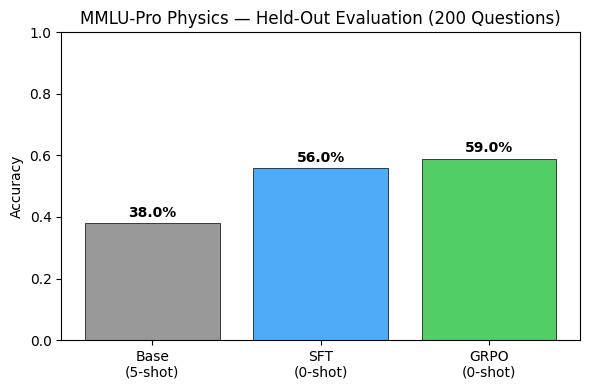

<Figure size 640x480 with 0 Axes>

In [ ]:
# Bar chart
models = ["Base\n(5-shot)", "SFT\n(0-shot)", "GRPO\n(0-shot)"]
accs = [base_metrics["accuracy"], sft_metrics["accuracy"], grpo_metrics["accuracy"]]
colors = ["#999999", "#4dabf7", "#51cf66"]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, accs, color=colors, edgecolor="black", linewidth=0.5)

for bar, acc in zip(bars, accs):
    plt.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{acc:.1%}", ha="center", va="bottom", fontweight="bold",
    )

plt.ylabel("Accuracy")
plt.title("MMLU-Pro Physics — Held-Out Evaluation (200 Questions)")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

save_path = "physics_rlvr/artifacts/evaluation_bar_chart.png"
plt.savefig(save_path)

In [ ]:
# Save aggregate results (all three metrics in one file for convenience)
results_out = {
    "eval_size": 200,
    "base": base_metrics,
    "sft": sft_metrics,
    "grpo": grpo_metrics,
}

with open("physics_rlvr/outputs/evaluation_results.json", "w") as f:
    json.dump(results_out, f, indent=2)
print("Aggregate metrics saved to physics_rlvr/outputs/evaluation_results.json")

# Verify generation files
print("\nGeneration files:")
for name in ["base", "sft", "grpo"]:
    path = f"physics_rlvr/outputs/{name}_generations.jsonl"
    n_lines = sum(1 for _ in open(path))
    print(f"  {path}  ({n_lines} lines)")

Aggregate metrics saved to physics_rlvr/outputs/evaluation_results.json

Generation files:
  physics_rlvr/outputs/base_generations.jsonl  (200 lines)
  physics_rlvr/outputs/sft_generations.jsonl  (200 lines)
  physics_rlvr/outputs/grpo_generations.jsonl  (200 lines)


## Step 7: Inspect Sample Outputs

Browse individual completions from each model and compare per-question performance.

The error analysis cell at the end counts:
- **GRPO correct, SFT wrong**: questions where GRPO's RL training produced a new correct answer that SFT missed
- **SFT correct, GRPO wrong**: questions where SFT's supervised answer was lost after RL

The net GRPO advantage (GRPO-only minus SFT-only) is the cleanest measure of RL contribution beyond the SFT baseline. A positive net with high format compliance confirms the improvement is genuine, not an artifact of answer extraction.

In [ ]:
# Reload full generations from JSONL (works after session restart)
def load_generations(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

base_results = load_generations("physics_rlvr/outputs/base_generations.jsonl")
sft_results  = load_generations("physics_rlvr/outputs/sft_generations.jsonl")
grpo_results = load_generations("physics_rlvr/outputs/grpo_generations.jsonl")
print(f"Loaded: {len(base_results)} base, {len(sft_results)} sft, {len(grpo_results)} grpo")

Loaded: 200 base, 200 sft, 200 grpo


In [ ]:
print("=== SFT model — sample outputs (first 5) ===\n")
for r in sft_results[:5]:
    status = "correct" if r["correct"] else "WRONG"
    print(f"Q: {r['question'][:100]}")
    print(f"GT: {r['ground_truth']} | Predicted: {r['predicted']} | {status}")
    print(f"Output: {r['completion'][:200]}")
    print("-" * 60)

=== SFT model — sample outputs (first 5) ===

Q: Two spheres of net charge +5e and -6e briefly come into contact. Afterward, which of the following i
GT: B | Predicted: B | correct
Output: <START_WORKING_OUT>
A: Let's think step by step. When the two spheres come into contact, charge will flow between them until they reach the same potential. The total charge is $5e - 6e = -e$. The fina
------------------------------------------------------------
Q: To perform a rescue, a lunar landing craft needs to hover just above the surface of the moon, which 
GT: H | Predicted: F | WRONG
Output: <START_WORKING_OUT>
A: Let's think step by step. The force of the exhaust must balance the weight of the lander, so $v_e \dot{m} = mg/6$, where $v_e$ is the exhaust velocity, $m$ is the mass of the la
------------------------------------------------------------
Q: The engine of a jet aircraft develops a thrust of 3000 lb. What horsepower does it develop at a velo
GT: H | Predicted: G | WRONG
Output: <STAR

In [ ]:
print("=== GRPO model — sample outputs (first 5) ===\n")
for r in grpo_results[:5]:
    status = "correct" if r["correct"] else "WRONG"
    print(f"Q: {r['question'][:100]}")
    print(f"GT: {r['ground_truth']} | Predicted: {r['predicted']} | {status}")
    print(f"Output: {r['completion'][:200]}")
    print("-" * 60)

=== GRPO model — sample outputs (first 5) ===

Q: Two spheres of net charge +5e and -6e briefly come into contact. Afterward, which of the following i
GT: B | Predicted: D | WRONG
Output: <START_WORKING_OUT>
A: Let's think step by step. When the two spheres come into contact, charge will flow between them until their potentials are equal. The total charge must be conserved, so the sum 
------------------------------------------------------------
Q: To perform a rescue, a lunar landing craft needs to hover just above the surface of the moon, which 
GT: H | Predicted: E | WRONG
Output: <START_WORKING_OUT>
A: Let's think step by step. We can use the rocket equation to solve this problem. The equation is $v_{\mathrm{e}} \ln \left(m_{\mathrm{i}} / m_{\mathrm{f}}\right)=h g$, where $v_{
------------------------------------------------------------
Q: The engine of a jet aircraft develops a thrust of 3000 lb. What horsepower does it develop at a velo
GT: H | Predicted: G | WRONG
Output: <START

In [ ]:
# Error analysis: questions GRPO got wrong but SFT got right (and vice versa)
grpo_only = []  # GRPO correct, SFT wrong
sft_only  = []  # SFT correct, GRPO wrong

for i in range(len(eval_data)):
    g_correct = grpo_results[i]["correct"]
    s_correct = sft_results[i]["correct"]
    if g_correct and not s_correct:
        grpo_only.append(i)
    elif s_correct and not g_correct:
        sft_only.append(i)

print(f"GRPO correct, SFT wrong: {len(grpo_only)} questions")
print(f"SFT correct, GRPO wrong: {len(sft_only)} questions")
print(f"Net GRPO advantage:      {len(grpo_only) - len(sft_only)} questions")

GRPO correct, SFT wrong: 27 questions
SFT correct, GRPO wrong: 21 questions
Net GRPO advantage:      6 questions


# Step 8: Fixing Metadata

In [1]:
import nbformat
import os

In [2]:
from google.colab import drive, files
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# List the notebook directory to confirm the file exists
os.listdir("/content/drive/MyDrive/grpo-verified-reasoner/physics_rlvr/new")

['04_merge_checkpoint_250.ipynb',
 '02_grpo_training.ipynb',
 '00_data_preparation.ipynb',
 '01_sft_warmup.ipynb',
 '03_evaluation.ipynb']

In [4]:
notebook_path = "/content/drive/MyDrive/grpo-verified-reasoner/physics_rlvr/new/03_evaluation.ipynb"

with open(notebook_path, "r") as f:
    nb = nbformat.read(f, as_version=4)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

with open(notebook_path, "w") as f:
    nbformat.write(nb, f)

print("Notebook fixed and saved successfully!")

Notebook fixed and saved successfully!
